RESUMO DO DATASET PARA TREINO
Linhas: 1450
Features totais usadas: 19
Numéricas: 17
Categóricas: 2

Categóricas:
['country', 'channel_tier']

Numéricas:
['title_length', 'title_word_count', 'title_uppercase_ratio', 'title_special_chars', 'title_has_number', 'title_sentiment', 'title_subjectivity', 'duration_segundos', 'dias_publicacao', 'subscriber_count', 'view_count_canal', 'video_count', 'description_word_count', 'age_days', 'channel_age_days', 'avg_views_per_video', 'view_subscriber_ratio']

TREINAMENTO E AVALIAÇÃO

Treinando: Linear Regression

--- Linear Regression ---
R² (log): 0.2772
RMSE (log): 1.3404
MAE (log): 1.0980
R² (original): 0.1033
RMSE (original): 101369.00
MAE (original): 25502.66
MAPE: 1.2735
CV R² médio: 0.3032 (+/- 0.0447)

Treinando: Ridge

--- Ridge ---
R² (log): 0.2573
RMSE (log): 1.3587
MAE (log): 1.1107
R² (original): 0.1000
RMSE (original): 101553.44
MAE (original): 25690.87
MAPE: 1.3864
CV R² médio: 0.2944 (+/- 0.0429)

Treinando: SVR (RBF)

--- SVR (RBF) 

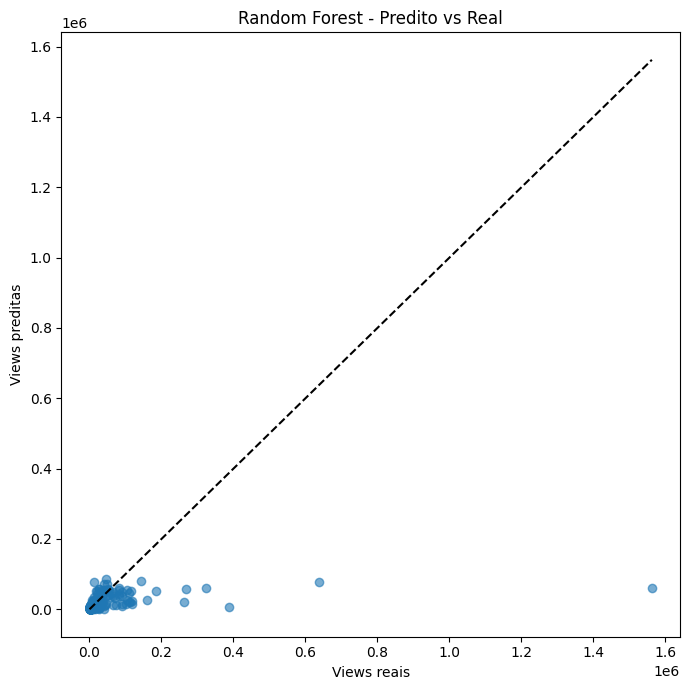

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
from pathlib import Path
import sys

ROOT: Path = Path.cwd().parent
sys.path.append(str(ROOT))
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# CONFIGURAÇÃO
# =========================================================

TARGET = "view_count"

# Colunas para remover do treino
# Ajuste conforme o seu dataset final
DROP_COLS = [
    # alvo
    "view_count",

    # vazamento / proxies de performance
    "like_count",
    "comment_count",
    "engagement_rate",
    "comment_rate",
    "like_rate",
    "like_comment_ratio",
    "views_per_day",

    # IDs / metadados / bruto
    "input_canal",
    "channel_id",
    "video_id",
    "url",
    "raw_json",
    "timestamp_execucao",
    "timestamp_execucao_canal",

    # strings brutas / datas cruas / redundantes
    "title",
    "description",
    "published_at",
    "published_at_canal",
    "duration",
    "title_processed",
    "input_canal_canal",
    "title_canal",
    "channel_title",
    "description_canal",
    "custom_url",

    # redundância potencial — escolha uma só se forem equivalentes
    # "age_days",
]

TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5


# =========================================================
# PREPARAÇÃO DO DATASET PRÉ-PROCESSADO
# =========================================================

def preparar_dataset_treino(
    df: pd.DataFrame,
    target: str = TARGET,
    drop_cols: list[str] | None = None,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE
):
    """
    Assume que o dataset já está pré-processado.
    Faz apenas:
      - remoção de colunas indevidas
      - separação X / y
      - split treino / teste
      - identificação de colunas numéricas e categóricas
    """
    df = df.copy()

    if drop_cols is None:
        drop_cols = []

    # manter apenas colunas que realmente existem
    cols_to_drop = [c for c in drop_cols if c in df.columns]

    if target not in df.columns:
        raise ValueError(f"Target '{target}' não encontrado no DataFrame.")

    # y em log
    y = np.log1p(df[target].astype(float))

    # X sem target e sem colunas indesejadas
    X = df.drop(columns=cols_to_drop, errors="ignore")

    # garante que target saiu
    if target in X.columns:
        X = X.drop(columns=[target])

    # separar tipos
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

    print("=" * 70)
    print("RESUMO DO DATASET PARA TREINO")
    print("=" * 70)
    print(f"Linhas: {len(df)}")
    print(f"Features totais usadas: {X.shape[1]}")
    print(f"Numéricas: {len(numeric_cols)}")
    print(f"Categóricas: {len(categorical_cols)}")

    if categorical_cols:
        print("\nCategóricas:")
        print(categorical_cols)

    if numeric_cols:
        print("\nNuméricas:")
        print(numeric_cols)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "feature_names_raw": X.columns.tolist()
    }


# =========================================================
# PIPELINES
# =========================================================

def criar_preprocessador(numeric_cols, categorical_cols, scale_numeric=True):
    """
    Cria um ColumnTransformer para:
      - imputar numéricas
      - opcionalmente escalar numéricas
      - imputar + one-hot em categóricas
    """
    transformers = []

    if numeric_cols:
        if scale_numeric:
            num_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ])
        else:
            num_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ])

        transformers.append(("num", num_pipe, numeric_cols))

    if categorical_cols:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        transformers.append(("cat", cat_pipe, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")


class ModeloRegressao:
    def __init__(self, nome, pipeline):
        self.nome = nome
        self.pipeline = pipeline
        self.historico = {}

    def treinar(self, X_train, y_train):
        print(f"\nTreinando: {self.nome}")
        self.pipeline.fit(X_train, y_train)

    def avaliar(self, X_test, y_test):
        y_pred_log = self.pipeline.predict(X_test)

        # escala original
        y_test_original = np.expm1(y_test)
        y_pred_original = np.expm1(y_pred_log)

        # proteção contra previsão negativa absurda após expm1
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)

        self.historico["y_pred_log"] = y_pred_log
        self.historico["y_pred_original"] = y_pred_original
        self.historico["y_test_log"] = y_test
        self.historico["y_test_original"] = y_test_original

        metricas = {
            "RMSE (log)": np.sqrt(mean_squared_error(y_test, y_pred_log)),
            "MAE (log)": mean_absolute_error(y_test, y_pred_log),
            "R² (log)": r2_score(y_test, y_pred_log),

            "RMSE (original)": np.sqrt(mean_squared_error(y_test_original, y_pred_original)),
            "MAE (original)": mean_absolute_error(y_test_original, y_pred_original),
            "R² (original)": r2_score(y_test_original, y_pred_original),
            "MAPE": mean_absolute_percentage_error(y_test_original, y_pred_original),
        }

        self.historico["metricas"] = metricas
        return metricas

    def cross_validate(self, X_train, y_train, cv=CV_FOLDS):
        kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(self.pipeline, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
        self.historico["cv_scores"] = scores
        return scores


def criar_modelos(numeric_cols, categorical_cols):
    """
    Cria pipelines separadas por modelo.
    """
    # Modelos lineares / SVR -> com escala
    prep_scaled = criar_preprocessador(numeric_cols, categorical_cols, scale_numeric=True)

    # Random Forest -> sem necessidade de escala
    prep_tree = criar_preprocessador(numeric_cols, categorical_cols, scale_numeric=False)

    modelos = {
        "Linear Regression": ModeloRegressao(
            "Linear Regression",
            Pipeline([
                ("prep", prep_scaled),
                ("model", LinearRegression())
            ])
        ),

        "Ridge": ModeloRegressao(
            "Ridge",
            Pipeline([
                ("prep", prep_scaled),
                ("model", Ridge(alpha=1.0))
            ])
        ),

        "SVR (RBF)": ModeloRegressao(
            "SVR (RBF)",
            Pipeline([
                ("prep", prep_scaled),
                ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
            ])
        ),

        "Random Forest": ModeloRegressao(
            "Random Forest",
            Pipeline([
                ("prep", prep_tree),
                ("model", RandomForestRegressor(
                    n_estimators=300,
                    max_depth=20,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                ))
            ])
        ),
    }

    return modelos


# =========================================================
# TREINO E COMPARAÇÃO
# =========================================================

def treinar_e_comparar_modelos(X_train, X_test, y_train, y_test, numeric_cols, categorical_cols):
    modelos = criar_modelos(numeric_cols, categorical_cols)
    resultados = {}

    print("\n" + "=" * 70)
    print("TREINAMENTO E AVALIAÇÃO")
    print("=" * 70)

    for nome, modelo in modelos.items():
        modelo.treinar(X_train, y_train)
        metricas = modelo.avaliar(X_test, y_test)
        cv_scores = modelo.cross_validate(X_train, y_train)

        resultados[nome] = {
            "modelo": modelo,
            "metricas": metricas,
            "cv_scores": cv_scores
        }

        print(f"\n--- {nome} ---")
        print(f"R² (log): {metricas['R² (log)']:.4f}")
        print(f"RMSE (log): {metricas['RMSE (log)']:.4f}")
        print(f"MAE (log): {metricas['MAE (log)']:.4f}")
        print(f"R² (original): {metricas['R² (original)']:.4f}")
        print(f"RMSE (original): {metricas['RMSE (original)']:.2f}")
        print(f"MAE (original): {metricas['MAE (original)']:.2f}")
        print(f"MAPE: {metricas['MAPE']:.4f}")
        print(f"CV R² médio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    return resultados


# =========================================================
# RELATÓRIO
# =========================================================

def gerar_relatorio(resultados):
    df_resultados = pd.DataFrame({
        nome: resultado["metricas"]
        for nome, resultado in resultados.items()
    }).T

    df_resultados["CV R² mean"] = [
        resultados[nome]["cv_scores"].mean() for nome in df_resultados.index
    ]
    df_resultados["CV R² std"] = [
        resultados[nome]["cv_scores"].std() for nome in df_resultados.index
    ]

    print("\n" + "=" * 70)
    print("RESULTADOS FINAIS")
    print("=" * 70)
    print(df_resultados.sort_values("R² (log)", ascending=False).to_string())

    melhor = df_resultados["R² (log)"].idxmax()
    print(f"\nMelhor modelo por R² (log): {melhor}")

    return df_resultados


# =========================================================
# PLOT OPCIONAL
# =========================================================

def plotar_pred_vs_real(resultados, nome_modelo="Random Forest"):
    modelo = resultados[nome_modelo]["modelo"]
    y_real = modelo.historico["y_test_original"]
    y_pred = modelo.historico["y_pred_original"]

    plt.figure(figsize=(7, 7))
    plt.scatter(y_real, y_pred, alpha=0.6)
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], "k--")
    plt.xlabel("Views reais")
    plt.ylabel("Views preditas")
    plt.title(f"{nome_modelo} - Predito vs Real")
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================

def main():
    # troque pelo seu arquivo
    df = pd.read_csv("merged.csv")

    dados = preparar_dataset_treino(
        df,
        target=TARGET,
        drop_cols=DROP_COLS,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    resultados = treinar_e_comparar_modelos(
        X_train=dados["X_train"],
        X_test=dados["X_test"],
        y_train=dados["y_train"],
        y_test=dados["y_test"],
        numeric_cols=dados["numeric_cols"],
        categorical_cols=dados["categorical_cols"]
    )

    relatorio = gerar_relatorio(resultados)

    # opcional
    plotar_pred_vs_real(resultados, nome_modelo="Random Forest")

    return relatorio, resultados


if __name__ == "__main__":
    relatorio, resultados = main()

In [6]:
pd.read_csv("merged.csv")

,input_canal,channel_id,video_id,title,description,published_at,channel_title,view_count,like_count,comment_count,...,subscriber_count,view_count_canal,video_count,timestamp_execucao_canal,description_word_count,age_days,channel_age_days,avg_views_per_video,view_subscriber_ratio,channel_tier
0,@canaltech,UC_bXJnsgwOqEPA_-6N6faKw,7XaLw-cpDIY,CT Responde: Tire suas dúvidas de tecnologia a...,🔥https://canalte.ch/motorola-live-junho🔥\n\n\n...,2026-06-26 10:20:01+00:00,Canaltech,1939,204,1,...,3700000.0,885775539.0,9168.0,2026-06-16 11:25:37+00:00,88.0,5110.0,5120.0,96616.005563,239.398794,large
1,@canaltech,UC_bXJnsgwOqEPA_-6N6faKw,j9IFCXfBszo,Anel que afere a pressão arterial: RingCon Gen...,O mercado de dispositivos vestíveis tem aprese...,2026-06-25 23:00:35+00:00,Canaltech,2337,352,17,...,3700000.0,885775539.0,9168.0,2026-06-16 11:25:37+00:00,88.0,5110.0,5120.0,96616.005563,239.398794,large
2,@canaltech,UC_bXJnsgwOqEPA_-6N6faKw,RLvO0DXhKKg,IBM ANUNCIA CHIP COM TECNOLOGIA REVOLUCIONÁRIA!,PREPAREM-SE PARA CELULAR MAIS POTENTES!\n\nA I...,2026-06-25 19:30:40+00:00,Canaltech,3526,474,6,...,3700000.0,885775539.0,9168.0,2026-06-16 11:25:37+00:00,88.0,5110.0,5120.0,96616.005563,239.398794,large
3,@canaltech,UC_bXJnsgwOqEPA_-6N6faKw,uHlOHBYgE2E,RELÓGIO DOS ÁRBITROS NA COPA CUSTA 20 MIL REAIS!,SMARTWATCH DE MILHÕES! \n\nVocê sabia que os r...,2026-06-25 18:01:41+00:00,Canaltech,4218,358,4,...,3700000.0,885775539.0,9168.0,2026-06-16 11:25:37+00:00,88.0,5110.0,5120.0,96616.005563,239.398794,large
4,@canaltech,UC_bXJnsgwOqEPA_-6N6faKw,b18dW_MqxWw,IPHONE DOURADO DO ROBERTO CARLOS PODE CUSTAR M...,DESCOBRIMOS QUAL É O IPHONE DO ROBERTO CARLOS!...,2026-06-25 16:01:45+00:00,Canaltech,27827,1943,39,...,3700000.0,885775539.0,9168.0,2026-06-16 11:25:37+00:00,88.0,5110.0,5120.0,96616.005563,239.398794,large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,@pasquadev,UCaftHbsPdXaHEwLQdIXGxbQ,M6bCWzCjLLA,Testei o TRAE SOLO no meu workflow real,O TRAE SOLO promete cobrir todo o ciclo de des...,2026-04-27 22:00:18+00:00,pasquadev,2740,168,23,...,26000.0,5829110.0,820.0,2026-06-16 11:25:37+00:00,75.0,4832.0,4842.0,7108.670732,224.196538,small
1446,@pasquadev,UCaftHbsPdXaHEwLQdIXGxbQ,I1FIaoXVkic,Ownership na veia.,Ownership na veia.\n#Dev #Ai #shorts,2026-04-26 23:01:02+00:00,pasquadev,13015,600,13,...,26000.0,5829110.0,820.0,2026-06-16 11:25:37+00:00,75.0,4832.0,4842.0,7108.670732,224.196538,small
1447,@pasquadev,UCaftHbsPdXaHEwLQdIXGxbQ,6dP5bFbnpdk,Anywhere Matcha,Anywhere Matcha\n#Dev #Ai #shorts,2026-04-24 01:12:49+00:00,pasquadev,6352,259,7,...,26000.0,5829110.0,820.0,2026-06-16 11:25:37+00:00,75.0,4832.0,4842.0,7108.670732,224.196538,small
1448,@pasquadev,UCaftHbsPdXaHEwLQdIXGxbQ,v6fZGG4uOc8,Karpathy provou que você não precisa de RAG,Todo mundo usa LLM pra gerar código. O Karpath...,2026-04-22 22:01:10+00:00,pasquadev,9010,815,42,...,26000.0,5829110.0,820.0,2026-06-16 11:25:37+00:00,75.0,4832.0,4842.0,7108.670732,224.196538,small


In [6]:
from pathlib import Path
import sys
import pandas as pd
ROOT: Path = Path.cwd().parent
sys.path.append(str(ROOT))
from src.core.predict.youtube_clustering import YoutubeVideoClusterAnalyzer


def test_clustering(df):
    """Testa o clustering com os dados"""
    print("\n" + "="*80)
    print("INICIANDO CLUSTERING")
    print("="*80)
    
    analyzer = YoutubeVideoClusterAnalyzer('merged_postprocessed.csv')
    analyzer.run_full_analysis(n_clusters=16,find_optimal=True, n_features=50)
    
    print("\nTeste concluído com sucesso!")
    print("\nArquivos gerados:")
    print("  - optimal_clusters.png")
    print("  - clusters_pca.png")
    print("  - clusters_tsne.png")
    print("  - cluster_summary.png")
    print("  - youtube_clusters_results.csv")
    
    return analyzer
test_clustering(df=pd.read_csv("merged_postprocessed.csv"))


INICIANDO CLUSTERING
🚀 INICIANDO ANÁLISE DE CLUSTERING
📊 Dataset Shape: (1450, 57)

📝 Primeiras linhas:
      video_id  view_count  like_count  comment_count  \
0  7XaLw-cpDIY        1939         204              1   
1  j9IFCXfBszo        2337         352             17   
2  RLvO0DXhKKg        3526         474              6   
3  uHlOHBYgE2E        4218         358              4   
4  b18dW_MqxWw       27827        1943             39   

                                     title_processed  title_length  \
0                       respond tir dúv tecnolog viv            53   
1  anel afer pressã arterial ringcon gen vei pra ...            69   
2               ibm anunc chip tecnolog revolucionár            47   
3                     relógi árbitr cop cust mil rea            48   
4              iphon dour robert carl pod cust 10000            62   

                               description_processed  title_word_count  \
0  dos mensal tecnolog complic cheg cheg respond ...     

In [7]:
import pandas as pd

df = pd.read_csv("youtube_clusters_results.csv")

cluster_col = "cluster_kmeans"

summary = (
    df.groupby(cluster_col)
      .agg(
          n_videos=("video_id", "count"),
          avg_views=("view_count", "mean"),
          median_views=("view_count", "median"),
          avg_engagement=("engagement_rate", "mean"),
          avg_virality=("virality_index", "mean"),
          avg_quality=("content_quality", "mean"),
          avg_freshness=("freshness_score", "mean")
      )
      .sort_values("n_videos", ascending=False)
)

print(summary)

                n_videos     avg_views  median_views  avg_engagement  \
cluster_kmeans                                                         
10                   368   7056.730978        3047.5        7.595549   
15                   162  63092.395062       41608.0        9.380404   
12                   112   7752.375000        3125.5        8.124280   
13                    81  38814.444444       25327.0        8.328197   
1                     75   5997.466667        2261.0       13.263494   
0                     74  11543.797297        6454.0        9.755005   
19                    58   9087.741379        6457.5        8.847214   
2                     58   5872.603448        2343.5        5.764466   
14                    55  38237.927273       30667.0        8.229912   
6                     53  83778.528302       56524.0        7.928792   
9                     49   9376.102041        4777.0        9.323275   
7                     48   3141.541667        1292.0       12.83

In [8]:
import re
from collections import Counter
import pandas as pd


# stopwords básicas PT-BR + EN
stopwords = {
    "de","da","do","das","dos","a","o","as","os","e","em","no","na","nos","nas","pra","pro","pelo","pela","pelos","pelas",
    "para","por","com","sem","um","uma","uns","umas","que","como","mais","menos",
    "é","ser","foi","são","ao","aos","à","às","se","não","sim","já","até","sobre",
    "the","a","an","and","or","of","to","in","on","for","with","is","are","be",
    "how","what","why","when","where","this","that","it"
}

def clean_title(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zà-ú0-9\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 2 and t not in stopwords]
    return tokens

cluster_keywords = {}

for cluster_id, group in df.groupby(cluster_col):
    all_tokens = []
    for title in group["title_processed"].fillna(""):
        all_tokens.extend(clean_title(title))
    
    top_words = Counter(all_tokens).most_common(15)
    cluster_keywords[cluster_id] = top_words

for cluster_id, words in cluster_keywords.items():
    print(f"\n=== Cluster {cluster_id} ===")
    print(words)


=== Cluster 0 ===
[('apple', 8), ('brasil', 6), ('iphon', 6), ('ultra', 5), ('xiaom', 4), ('compr', 4), ('digital', 4), ('celul', 4), ('eua', 4), ('sab', 4), ('melhor', 4), ('gta', 4), ('mythos', 4), ('vai', 4), ('alex', 4)]

=== Cluster 1 ===
[('liv', 45), ('dia', 11), ('claud', 9), ('bugs', 8), ('bor', 7), ('baterpap', 7), ('bgeeks', 7), ('brej', 7), ('design', 6), ('seman', 6), ('devops', 6), ('viv', 5), ('constru', 5), ('projet', 5), ('coding', 4)]

=== Cluster 2 ===
[('brasil', 9), ('bat', 6), ('celul', 6), ('unboxing', 6), ('ultra', 5), ('vai', 5), ('xiaom', 4), ('cheg', 4), ('review', 4), ('cop', 4), ('shorts', 3), ('17t', 3), ('fon', 3), ('nov', 3), ('anális', 3)]

=== Cluster 3 ===
[('perd', 1), ('liv', 1), ('fic', 1), ('maluc', 1), ('agor', 1), ('vai', 1), ('compr', 1), ('gam', 1)]

=== Cluster 4 ===
[('rtx', 13), ('compr', 6), ('dlss', 5), ('tud', 4), ('mud', 4), ('agor', 3), ('fic', 3), ('5070', 3), ('5060', 3), ('vai', 3), ('amd', 3), ('prec', 2), ('volt', 2), ('desculp',

In [9]:
for cluster_id, group in df.groupby(cluster_col):
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*80}")
    
    print("\nTop palavras:")
    words = cluster_keywords[cluster_id]
    print(", ".join([f"{w} ({c})" for w, c in words[:10]]))
    
    print("\nExemplos de vídeos:")
    sample_titles = group["title_processed"].dropna().head(5).tolist()
    for t in sample_titles:
        print(f"- {t}")


CLUSTER 0

Top palavras:
apple (8), brasil (6), iphon (6), ultra (5), xiaom (4), compr (4), digital (4), celul (4), eua (4), sab (4)

Exemplos de vídeos:
- respond tir dúv tecnolog viv
- anel afer pressã arterial ringcon gen vei pra mud tud
- ibm anunc chip tecnolog revolucionár
- relógi árbitr cop cust mil rea
- balli jib cosm vector robôs pets der errad

CLUSTER 1

Top palavras:
liv (45), dia (11), claud (9), bugs (8), bor (7), baterpap (7), bgeeks (7), brej (7), design (6), seman (6)

Exemplos de vídeos:
- ste machin pro brasileirinh
- aind rei vam retest amd ryzen 5800x3d viv
- 100000 viv hor test
- test viv pap gal
- bor baterpap liv bgeeks

CLUSTER 2

Top palavras:
brasil (9), bat (6), celul (6), unboxing (6), ultra (5), vai (5), xiaom (4), cheg (4), review (4), cop (4)

Exemplos de vídeos:
- biciclet xiaom transform calor bat
- jov bat bluevolt 6500mah mediatek 7360 turb shorts
- xiaom 17t cheg brasil cont dimensity 8500 ultra 12512gb bat 6500 mah
- realm cheg bat 6550 mah subm